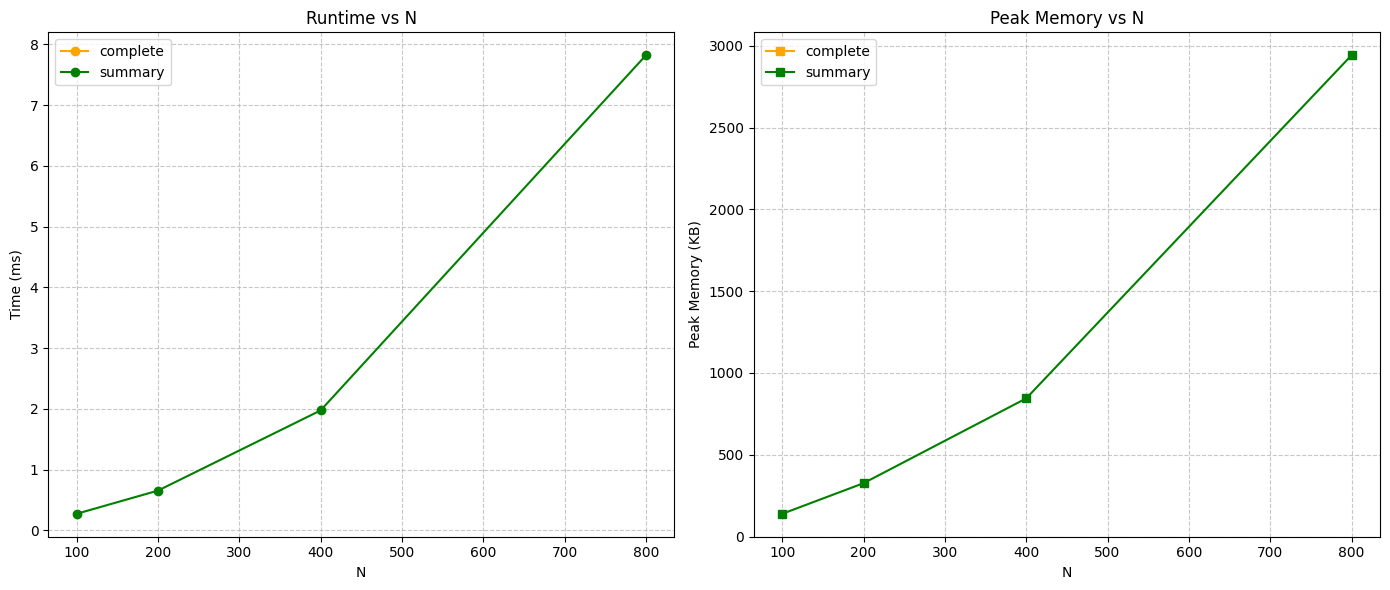

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('measurements_mac.csv')

df_avg = df.groupby(['Version', 'N']).mean(numeric_only=True).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

versions = ['complete', 'summary']
colors = {'complete': 'orange', 'summary': 'green'}

for v in versions:
    subset = df_avg[df_avg['Version'] == v]
    
    # Plot Time_ms vs N
    ax1.plot(subset['N'], subset['Time_ms'], marker='o', label=f'{v}', color=colors[v])
    
    # Plot PeakMemory_KB vs N
    ax2.plot(subset['N'], subset['PeakMemory_KB'], marker='s', label=f'{v}', color=colors[v])

ax1.set_title('Runtime vs N')
ax1.set_xlabel('N')
ax1.set_ylabel('Time (ms)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title('Peak Memory vs N')
ax2.set_xlabel('N')
ax2.set_ylabel('Peak Memory (KB)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('performance_comparison.png')
plt.show()